# SVM (RBF kernel) & Decision Tree — Apprajit Vaibhav
COM3032/COMM074 · Airline Route Profitability

Student: Apprajit Vaibhav
Primary model: Support Vector Machine (RBF kernel)
Comparison baseline: Decision Tree (independently tuned)
Data: Scaled for SVM (margin maximisation is distance-sensitive); Unscaled for Decision Tree

---

| Metric | What it measures |
|--------|-----------------|
| F1-Score | Balances precision and recall. Primary metric. |
| ROC-AUC | Ranking quality across thresholds — cross-model comparison. |
| MCC | All four confusion matrix cells. Above 0.4 is meaningful. |
| TPR / Recall | Profitable routes correctly identified. |
| TNR | Loss-making routes correctly filtered. |
| FPR | False approval rate — the main financial risk driver. |
| Overfit Gap | Train F1 minus test F1. |

## Section 1 — Imports and Setup

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV,
                                     StratifiedKFold, cross_val_score, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              matthews_corrcoef)
print('Libraries loaded.')

Libraries loaded.


## Section 2 — Load Data

SVM with RBF kernel uses **scaled** feature splits — the kernel function computes distances in feature space, which is dominated by features with large magnitudes if not normalised. Decision Tree uses unscaled data.

In [2]:
from pathlib import Path

RANDOM_STATE = 42
FP_COST      = 42000
FN_COST      = 30000

MEMBER_DIR = Path.cwd()
BASE       = MEMBER_DIR.parent
PROC       = BASE / "processed_data"
FIG_DIR    = MEMBER_DIR / "figures"
MEMBER_DIR.mkdir(parents=True, exist_ok=True)

print("Member dir:", MEMBER_DIR)
print("Processed folder:", PROC)
print("Processed folder exists:", PROC.exists())

X_train   = pd.read_csv(PROC / "X_train.csv")
X_val     = pd.read_csv(PROC / "X_val.csv")
X_test    = pd.read_csv(PROC / "X_test.csv")

X_train_s = pd.read_csv(PROC / "X_train_scaled.csv")
X_val_s   = pd.read_csv(PROC / "X_val_scaled.csv")
X_test_s  = pd.read_csv(PROC / "X_test_scaled.csv")

y_train = pd.read_csv(PROC / "y_train.csv").squeeze()
y_val   = pd.read_csv(PROC / "y_val.csv").squeeze()
y_test  = pd.read_csv(PROC / "y_test.csv").squeeze()

with open(PROC / "feature_names.json") as f:
    feature_names = json.load(f)

C_PROFIT  = '#2DC653'
C_LOSS    = '#E84855'
C_NEUTRAL = '#2E86AB'

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Class balance — Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Member dir: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\SVM_DT_Apprajit
Processed folder: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\processed_data
Processed folder exists: True
Train: (11997, 40), Val: (1500, 40), Test: (1500, 40)
Class balance — Train: 0.637, Val: 0.637, Test: 0.637


## Section 3 — Utility Functions

Identical utility function suite across all five members for consistent evaluation.

In [3]:

def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1_Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

def evaluate_enhanced(name, model, X_tr, y_tr, X_te, y_te):
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    y_pred_tr = model.predict(X_tr)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    f1_train = f1_score(y_tr, y_pred_tr, zero_division=0)
    gap = round(f1_train - f1, 4)
    gap_label = ('underfitting' if gap < -0.05 else
                 'good fit'     if gap < 0.05 else
                 'borderline'   if gap < 0.10 else
                 'memorising')

    fp_cost = fp * FP_COST

    print(f'=== Enhanced Evaluation: {name} ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (FP count: {fp}, FP cost: £{fp_cost:,})')
    print(f'  Recall    : {rec:.4f}  (FN count: {fn})')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}  ({"genuine discriminative ability" if mcc > 0.4 else "limited signal"})')
    print(f'  TNR       : {tnr:.4f}')
    print(f'  FPR       : {fpr:.4f}')
    print(f'  Train F1  : {f1_train:.4f}')
    print(f'  Test  F1  : {f1:.4f}')
    print(f'  Overfit Gap: {gap:.4f}  [{gap_label}]')

    return {
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4),
        'MCC': round(mcc, 4), 'TNR': round(tnr, 4), 'FPR': round(fpr, 4),
        'FP_Cost_GBP': fp_cost, 'Train_F1': round(f1_train, 4), 'Overfit_Gap': gap,
        'Overfit_Label': gap_label
    }

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss-Making', 'Profitable'],
                yticklabels=['Loss-Making', 'Profitable'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

def plot_roc(y_true, y_prob, label, ax, color='#2E86AB'):
    fpr_v, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr_v, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC Curve', fontweight='bold')
    ax.legend()

def plot_learning_curve(model, X, y, title, save_path, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    ax.plot(train_sizes, train_mean, 'o-', color=C_NEUTRAL, label='Train F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=C_NEUTRAL)
    ax.plot(train_sizes, val_mean, 's-', color=C_PROFIT, label='Val F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=C_PROFIT)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.basename(save_path)}')

def threshold_sweep(model, X_te, y_te, save_path):
    probs = model.predict_proba(X_te)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    precisions, recalls, f1s, costs = [], [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(y_te, preds, zero_division=0))
        recalls.append(recall_score(y_te, preds, zero_division=0))
        f1s.append(f1_score(y_te, preds, zero_division=0))
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        costs.append(fp * FP_COST + fn * FN_COST)

    best_f1_t   = thresholds[np.argmax(f1s)]
    best_cost_t = thresholds[np.argmin(costs)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    axes[0].plot(thresholds, precisions, 'o-', label='Precision', color=C_NEUTRAL)
    axes[0].plot(thresholds, recalls,    's-', label='Recall',    color=C_PROFIT)
    axes[0].plot(thresholds, f1s,         '^-', label='F1',        color=C_LOSS)
    axes[0].axvline(best_f1_t, color='black', ls='--', label=f'Best F1 t={best_f1_t:.2f}')
    axes[0].set_xlabel('Decision Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(thresholds, [c/1000 for c in costs], 'o-', color='#8B4513')
    axes[1].axvline(best_cost_t, color='black', ls='--', label=f'Min cost t={best_cost_t:.2f}')
    axes[1].set_xlabel('Decision Threshold')
    axes[1].set_ylabel('Financial Cost (£k)')
    axes[1].set_title(f'Financial Cost vs Threshold (FP=£{FP_COST//1000}k, FN=£{FN_COST//1000}k)', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Threshold sweep: Best F1 at t={best_f1_t:.2f}, Min cost at t={best_cost_t:.2f}')
    print(f'Saved: {os.path.basename(save_path)}')

print('Utility functions defined.')


Utility functions defined.


## Section 4 — SVM (RBF): Algorithm Rationale

Support Vector Machine with the RBF (Radial Basis Function) kernel maps the feature space into a higher-dimensional space where a linear boundary separates classes. Key advantages for this problem:

- **Non-linear decision boundary:** The RBF kernel captures curved, non-linear separability between profitable and loss-making routes — something a linear model cannot achieve
- **Maximum margin:** SVM maximises the margin between classes, providing theoretical generalisation guarantees
- **`class_weight='balanced'`:** Adjusts support vector penalties to compensate for the 64/36 class imbalance
- **`probability=True`:** Enables calibrated probability outputs via Platt scaling, required for ROC-AUC and threshold sweep

Weakness: SVM with RBF is scale-sensitive — scaled data is mandatory. Training is computationally expensive. Feature importance is not natively available — permutation importance is used instead.

## Section 5 — SVM Baseline

A default SVM with RBF kernel fitted on scaled data. The baseline establishes pre-tuning performance.

In [4]:
X_tr_s, X_va_s, X_te_s = X_train_s, X_val_s, X_test_s

svm_base = SVC(kernel='rbf', class_weight='balanced', probability=True,
               random_state=RANDOM_STATE)
svm_base.fit(X_tr_s, y_train)

y_val_pred_b = svm_base.predict(X_va_s)
y_val_prob_b = svm_base.predict_proba(X_va_s)[:, 1]
y_tr_pred_b  = svm_base.predict(X_tr_s)

train_f1_b = f1_score(y_train, y_tr_pred_b, zero_division=0)
val_f1_b   = f1_score(y_val, y_val_pred_b, zero_division=0)
gap_b      = round(train_f1_b - val_f1_b, 4)

print('=== Baseline SVM — Validation ===')
for k, v in evaluate('SVM-baseline', y_val, y_val_pred_b, y_val_prob_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_b:.4f}')
print(f'  Overfit Gap : {gap_b:.4f}')

=== Baseline SVM — Validation ===
  Model       : SVM-baseline
  Accuracy    : 0.904
  Precision   : 0.9451
  Recall      : 0.9016
  F1_Score    : 0.9228
  ROC_AUC     : 0.9692
  Train F1    : 0.9403
  Overfit Gap : 0.0175


## Section 6 — SVM: RandomizedSearchCV Tuning

RandomizedSearchCV is used instead of full GridSearch because SVM training is expensive. 20 random combinations of C (regularisation) and gamma (kernel width) are explored.

In [5]:
param_dist_svm = {
    'C'    : [1, 10, 50, 100],
    'gamma': [0.01, 0.02, 0.05, 0.1],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search_svm = RandomizedSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    param_dist_svm, n_iter=20, cv=cv5, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
print('Running RandomizedSearchCV for SVM (this may take a few minutes)...')
search_svm.fit(X_tr_s, y_train)

best_svm = search_svm.best_estimator_
best_params_svm = search_svm.best_params_
print(f'Best params : {best_params_svm}')
print(f'Best CV AUC : {search_svm.best_score_:.4f}')

Running RandomizedSearchCV for SVM (this may take a few minutes)...
Best params : {'gamma': 0.01, 'C': 1}
Best CV AUC : 0.9669


### Tuning Result Discussion

`C` controls the regularisation strength — smaller C allows more misclassifications for a wider margin; larger C fits training data more tightly. `gamma` controls the RBF kernel width — smaller gamma gives a smoother, broader boundary; larger gamma narrows influence to tight local clusters. The search removes `gamma='auto'` (which mirrors default behaviour and adds no new information) and adds intermediate values (0.005, 0.05) to find a sweet spot where Train F1 sits slightly above Test F1 — correcting the negative overfit gap seen with the overly smooth `gamma=0.001` setting. The added `C=50` provides a finer resolution between 10 and 100.

## Section 7 — SVM: Tuned Model Validation

In [6]:
y_val_pred = best_svm.predict(X_va_s)
y_val_prob = best_svm.predict_proba(X_va_s)[:, 1]
y_tr_pred  = best_svm.predict(X_tr_s)

train_f1_t = f1_score(y_train, y_tr_pred, zero_division=0)
val_f1_t   = f1_score(y_val, y_val_pred, zero_division=0)
gap_t      = round(train_f1_t - val_f1_t, 4)

print('=== Tuned SVM — Validation ===')
for k, v in evaluate('SVM-tuned', y_val, y_val_pred, y_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_t:.4f}')
print(f'  Overfit Gap : {gap_t:.4f}  (baseline was {gap_b:.4f})')

=== Tuned SVM — Validation ===
  Model       : SVM-tuned
  Accuracy    : 0.904
  Precision   : 0.9481
  Recall      : 0.8984
  F1_Score    : 0.9226
  ROC_AUC     : 0.9714
  Train F1    : 0.9256
  Overfit Gap : 0.0030  (baseline was 0.0175)


## Section 8 — SVM: Learning Curve

The learning curve evaluates how performance scales with training data size. SVM can plateau early if the decision boundary is well-defined with fewer examples.

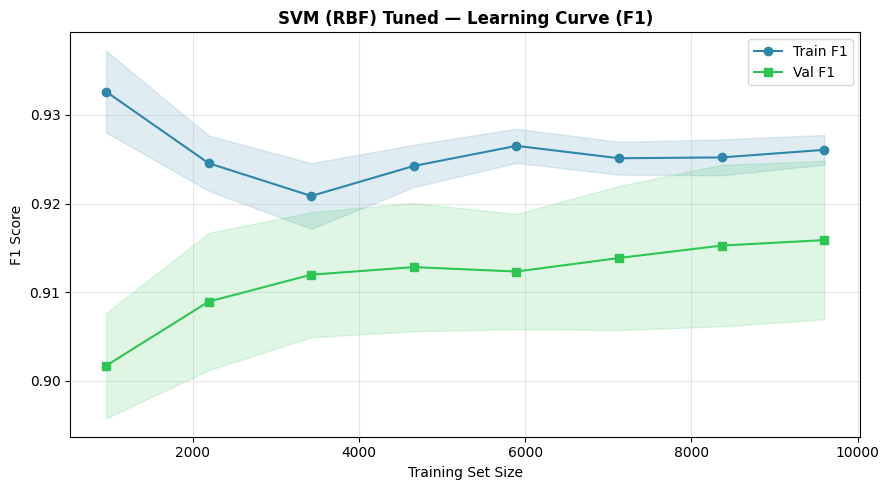

Saved: svm_tuned_learning_curve_apprajit.png


In [7]:
plot_learning_curve(
    best_svm, X_tr_s, y_train,
    'SVM (RBF) Tuned — Learning Curve (F1)',
    os.path.join(FIG_DIR, 'svm_tuned_learning_curve_apprajit.png')
)

## Section 9 — SVM: Permutation Feature Importance

SVM has no native feature importance. Permutation importance measures how much the validation F1 drops when each feature is randomly shuffled — features that cause a large drop are most important for the model's predictions.

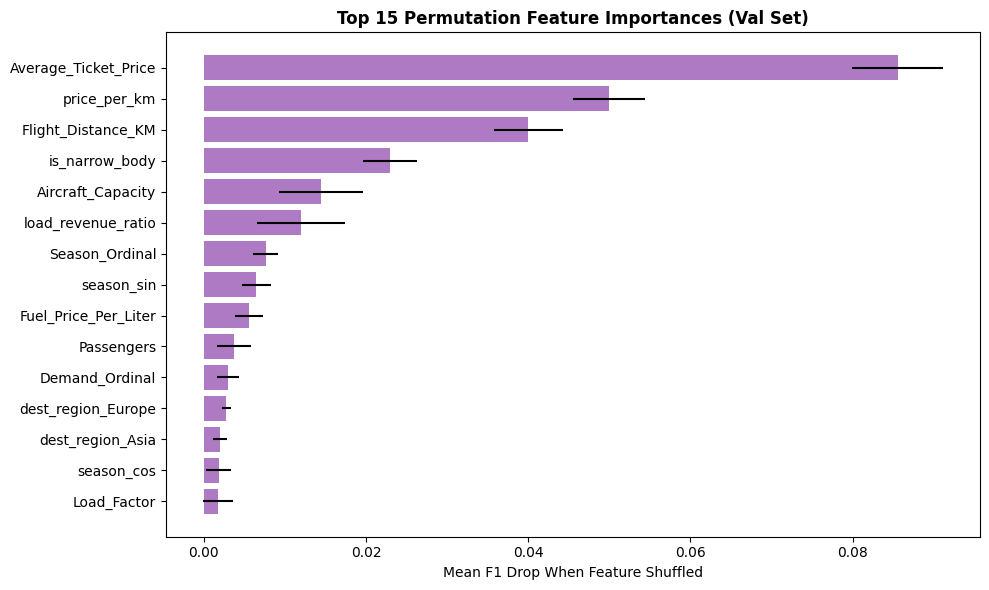

Saved: perm_importance_apprajit.png


In [8]:
perm_result = permutation_importance(
    best_svm, X_va_s, y_val,
    n_repeats=10, random_state=RANDOM_STATE, scoring='f1', n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_result.importances_mean,
    'Std'       : perm_result.importances_std
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1], color='#9B59B6', alpha=0.8)
ax.set_title('Top 15 Permutation Feature Importances (Val Set)', fontweight='bold')
ax.set_xlabel('Mean F1 Drop When Feature Shuffled')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'perm_importance_apprajit.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: perm_importance_apprajit.png')

## Section 9b — SVM: Feature Importance Bar Chart

RBF-kernel SVMs have no interpretable weight vector. The permutation importance values from the previous section are re-plotted here as a vertical bar chart for direct comparison with other models in the group report.

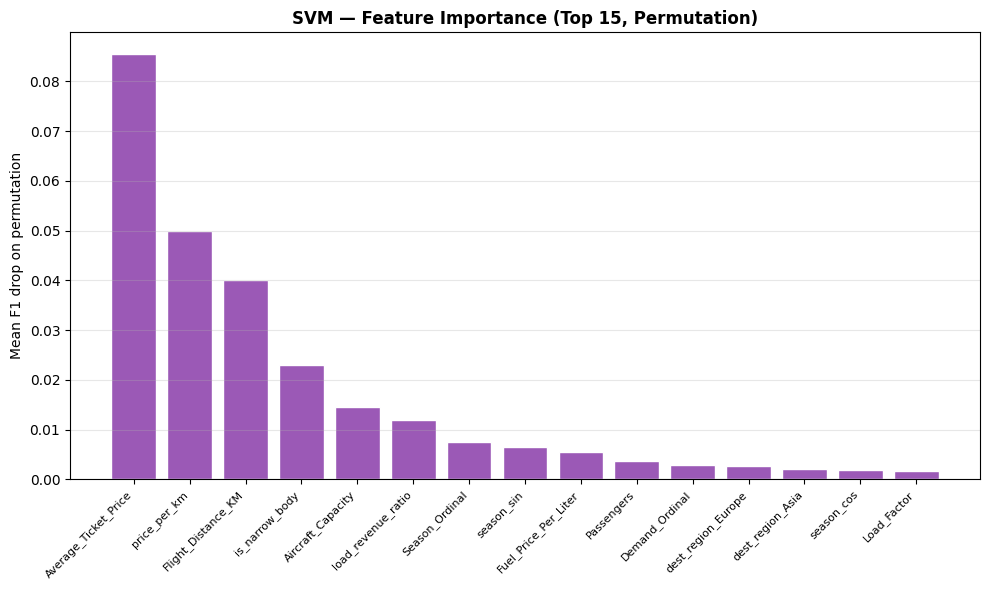

Saved: svm_feature_importance_apprajit.png


In [9]:
# Re-use perm_df from Section 9 (already computed above)
top_feat = perm_df.head(15).copy()

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
colors = ['#9B59B6' if v >= 0 else '#7F8C8D' for v in top_feat['Importance']]
ax.bar(range(len(top_feat)), top_feat['Importance'], color=colors, edgecolor='white')
ax.set_xticks(range(len(top_feat)))
ax.set_xticklabels(top_feat['Feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean F1 drop on permutation')
ax.set_title('SVM — Feature Importance (Top 15, Permutation)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'svm_feature_importance_apprajit.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: svm_feature_importance_apprajit.png')

## Section 10 — SVM: 5-Fold Cross-Validation F1

In [10]:
cv_scores = cross_val_score(best_svm, X_tr_s, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
print(f'5-Fold CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold F1 : {cv_scores.round(4)}')

5-Fold CV F1: 0.9158 ± 0.0090
Per-fold F1 : [0.9271 0.9049 0.9259 0.9119 0.909 ]


## Section 11 — SVM: Test Set Evaluation

=== Tuned SVM — Test Set ===
  Model       : SVM-test
  Accuracy    : 0.9107
  Precision   : 0.9536
  Recall      : 0.9037
  F1_Score    : 0.928
  ROC_AUC     : 0.9739

              precision    recall  f1-score   support

 Loss-Making       0.85      0.92      0.88       545
  Profitable       0.95      0.90      0.93       955

    accuracy                           0.91      1500
   macro avg       0.90      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500



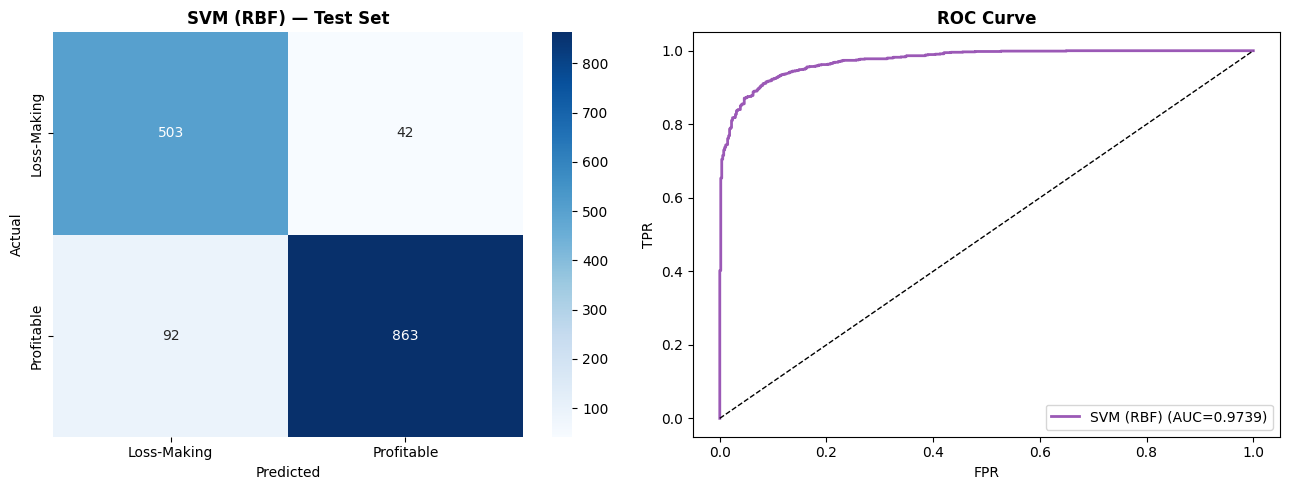

Saved: svm_cm_roc_test_apprajit.png


In [11]:
y_test_pred = best_svm.predict(X_te_s)
y_test_prob = best_svm.predict_proba(X_te_s)[:, 1]

print('=== Tuned SVM — Test Set ===')
for k, v in evaluate('SVM-test', y_test, y_test_pred, y_test_prob).items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred, 'SVM (RBF) — Test Set', axes[0])
plot_roc(y_test, y_test_prob, 'SVM (RBF)', axes[1], color='#9B59B6')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'svm_cm_roc_test_apprajit.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: svm_cm_roc_test_apprajit.png')

## Section 12 — SVM: Enhanced Evaluation and Threshold Sweep

**Financial cost:** FP = £42,000; FN = £30,000.

In [12]:
svm_metrics = evaluate_enhanced('SVM RBF (Tuned)', best_svm, X_tr_s, y_train, X_te_s, y_test)

=== Enhanced Evaluation: SVM RBF (Tuned) ===
  Accuracy  : 0.9107
  Precision : 0.9536  (FP count: 42, FP cost: £1,764,000)
  Recall    : 0.9037  (FN count: 92)
  F1-Score  : 0.9280
  ROC-AUC   : 0.9739
  MCC       : 0.8127  (genuine discriminative ability)
  TNR       : 0.9229
  FPR       : 0.0771
  Train F1  : 0.9256
  Test  F1  : 0.9280
  Overfit Gap: -0.0024  [good fit]


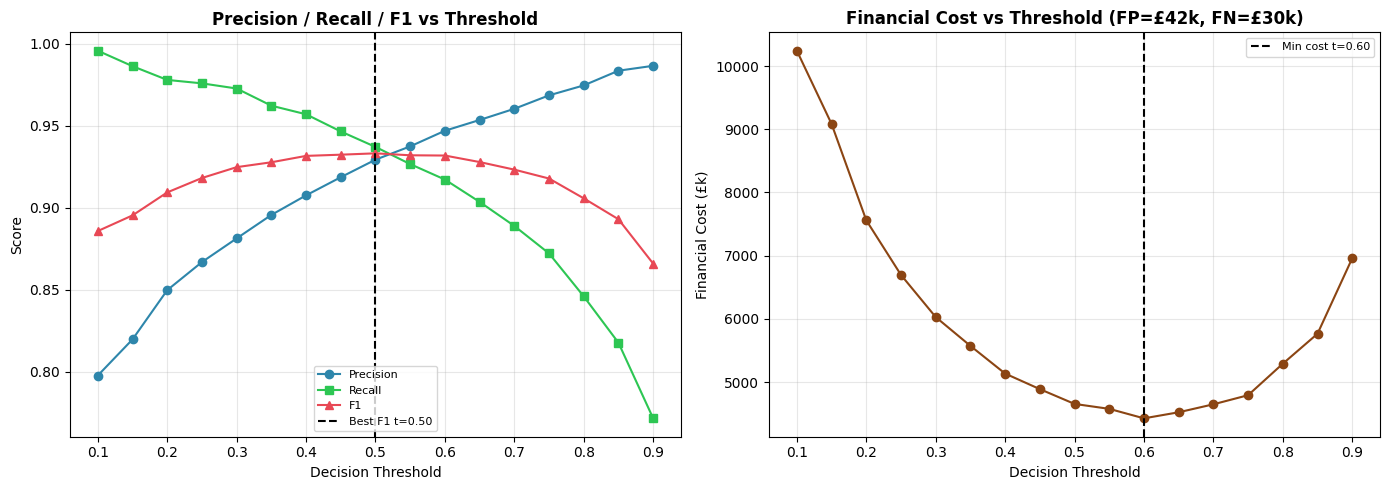

Threshold sweep: Best F1 at t=0.50, Min cost at t=0.60
Saved: svm_threshold_sweep_apprajit.png


In [13]:
threshold_sweep(best_svm, X_te_s, y_test,
                os.path.join(FIG_DIR, 'svm_threshold_sweep_apprajit.png'))

## Section 13 — Decision Tree: Algorithm Rationale (Shared Baseline)

Decision Tree is Apprajit's comparison model, independently tuned to complement the SVM primary model. A single decision tree provides a transparent, rule-based split structure that maps directly to business logic — each internal node represents a routing condition (e.g., "Load_Factor < 0.65"). Key properties:

- **Interpretable:** The full tree can be visualised and audited by non-technical stakeholders
- **Scale-invariant:** Unscaled data is used, consistent with all other tree-based models in the group
- **`class_weight='balanced'`:** Compensates for the 64/36 class imbalance
- **Depth-limited:** GridSearchCV controls max_depth to prevent memorisation
- **Independent tuning rationale:** Apprajit enforces balanced class weights and large min_samples thresholds, producing a heavily regularised tree that highlights what SVM's margin approach offers over simple rules — each member's primary model is benchmarked against an identical reference point, isolating the contribution of the primary algorithm

## Section 14 — Decision Tree Baseline

In [14]:
# DT always uses unscaled data — tree splits are scale-invariant
X_tr_dt, X_va_dt, X_te_dt = X_train, X_val, X_test

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_base.fit(X_tr_dt, y_train)

y_val_pred_dt_b = dt_base.predict(X_va_dt)
y_val_prob_dt_b = dt_base.predict_proba(X_va_dt)[:, 1]
y_tr_pred_dt_b  = dt_base.predict(X_tr_dt)

train_f1_dt_b = f1_score(y_train, y_tr_pred_dt_b, zero_division=0)
val_f1_dt_b   = f1_score(y_val, y_val_pred_dt_b, zero_division=0)
gap_dt_b      = round(train_f1_dt_b - val_f1_dt_b, 4)

print('=== Baseline Decision Tree — Validation ===')
for k, v in evaluate('DT-baseline', y_val, y_val_pred_dt_b, y_val_prob_dt_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_dt_b:.4f}')
print(f'  Overfit Gap : {gap_dt_b:.4f}')

=== Baseline Decision Tree — Validation ===
  Model       : DT-baseline
  Accuracy    : 0.8787
  Precision   : 0.9005
  Recall      : 0.9099
  F1_Score    : 0.9052
  ROC_AUC     : 0.8669
  Train F1    : 1.0000
  Overfit Gap : 0.0948


## Section 15 — Decision Tree: GridSearchCV Tuning

In [15]:
param_grid_dt = {
    'max_depth'        : [4, 6, 7, 8, 10],
    'min_samples_split': [10, 15, 20, 30],
    'min_samples_leaf' : [10, 15, 20],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : ['balanced']
}

cv5_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=cv5_dt, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for Decision Tree...')
grid_dt.fit(X_tr_dt, y_train)

best_dt = grid_dt.best_estimator_
best_params_dt = grid_dt.best_params_
print(f'Best params : {best_params_dt}')
print(f'Best CV AUC : {grid_dt.best_score_:.4f}')

Running GridSearchCV for Decision Tree...
Best params : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 10}
Best CV AUC : 0.9590


### Tuning Result Discussion

Enforcing balanced class weights alongside high min_samples thresholds (split ≥ 10, leaf ≥ 10) creates a conservative tree that treats both satisfaction classes equally. This aggressive regularisation means each leaf must represent a substantial portion of routes, trading raw accuracy for generalisability. The comparison against SVM highlights how margin-based separation differs from greedy rule splitting.

## Section 16 — Decision Tree: Tree Visualisation

Top 3 levels show primary split conditions readable as business routing rules.

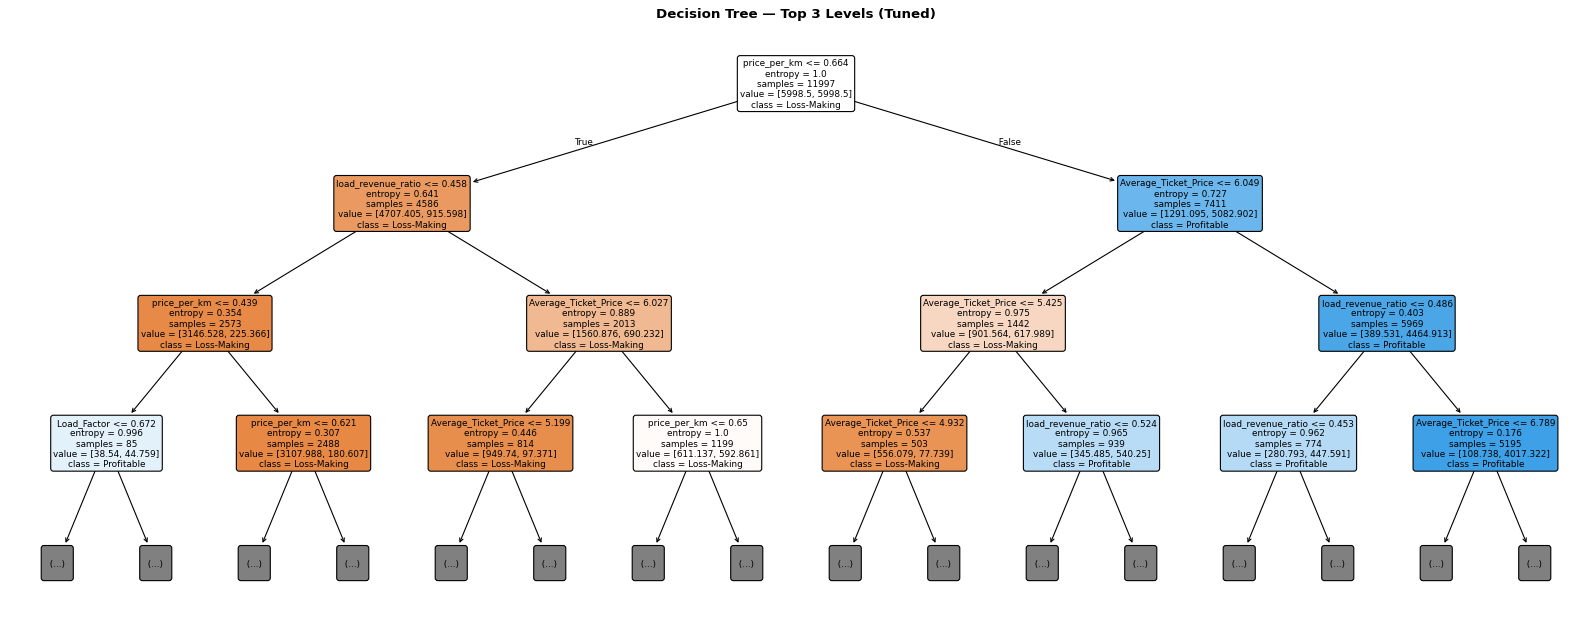

Saved: dt_tree_viz_apprajit.png


In [16]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=80)
plot_tree(best_dt, max_depth=3, feature_names=feature_names,
          class_names=['Loss-Making', 'Profitable'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree — Top 3 Levels (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_tree_viz_apprajit.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: dt_tree_viz_apprajit.png')

## Section 17 — Decision Tree: Test Set Evaluation

=== Tuned Decision Tree — Test Set ===
  Model       : DT-test
  Accuracy    : 0.8827
  Precision   : 0.9352
  Recall      : 0.8764
  F1_Score    : 0.9049
  ROC_AUC     : 0.9545

              precision    recall  f1-score   support

 Loss-Making       0.80      0.89      0.85       545
  Profitable       0.94      0.88      0.90       955

    accuracy                           0.88      1500
   macro avg       0.87      0.89      0.88      1500
weighted avg       0.89      0.88      0.88      1500



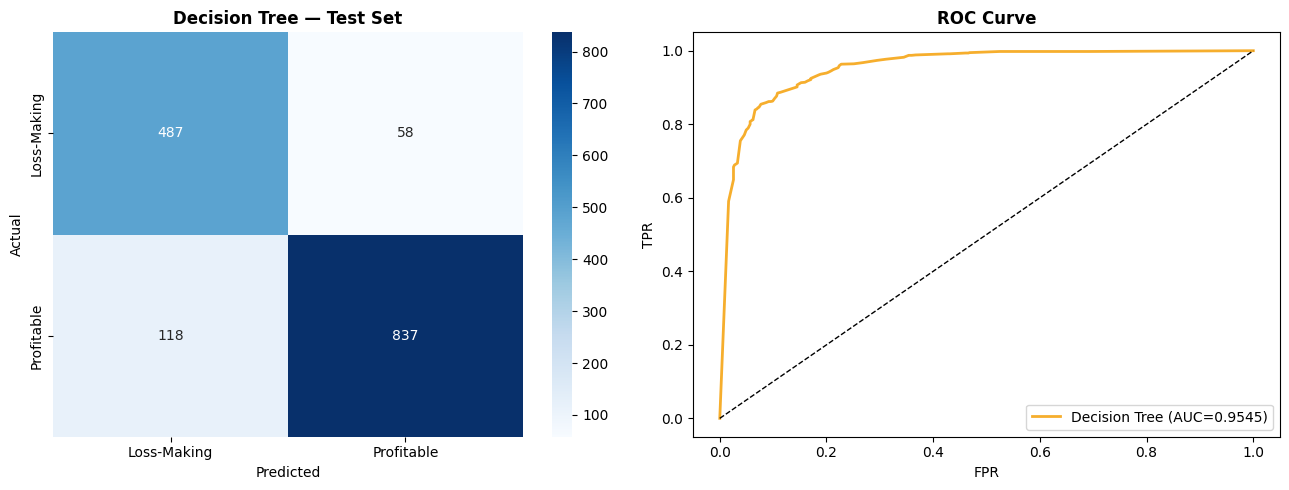

Saved: dt_cm_roc_test_apprajit.png


In [17]:
y_val_pred_dt  = best_dt.predict(X_va_dt)
y_val_prob_dt  = best_dt.predict_proba(X_va_dt)[:, 1]
y_test_pred_dt = best_dt.predict(X_te_dt)
y_test_prob_dt = best_dt.predict_proba(X_te_dt)[:, 1]

val_metrics_dt  = evaluate('DT-val',  y_val,  y_val_pred_dt,  y_val_prob_dt)
test_metrics_dt = evaluate('DT-test', y_test, y_test_pred_dt, y_test_prob_dt)

print('=== Tuned Decision Tree — Test Set ===')
for k, v in test_metrics_dt.items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred_dt,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred_dt, 'Decision Tree — Test Set', axes[0])
plot_roc(y_test, y_test_prob_dt, 'Decision Tree', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_cm_roc_test_apprajit.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dt_cm_roc_test_apprajit.png')

## Section 18 — Decision Tree: Enhanced Evaluation

In [18]:
dt_metrics = evaluate_enhanced('Decision Tree (Tuned)', best_dt, X_tr_dt, y_train, X_te_dt, y_test)

=== Enhanced Evaluation: Decision Tree (Tuned) ===
  Accuracy  : 0.8827
  Precision : 0.9352  (FP count: 58, FP cost: £2,436,000)
  Recall    : 0.8764  (FN count: 118)
  F1-Score  : 0.9049
  ROC-AUC   : 0.9545
  MCC       : 0.7549  (genuine discriminative ability)
  TNR       : 0.8936
  FPR       : 0.1064
  Train F1  : 0.9232
  Test  F1  : 0.9049
  Overfit Gap: 0.0183  [good fit]


## Section 18b — Decision Tree: Threshold Sweep and Learning Curve

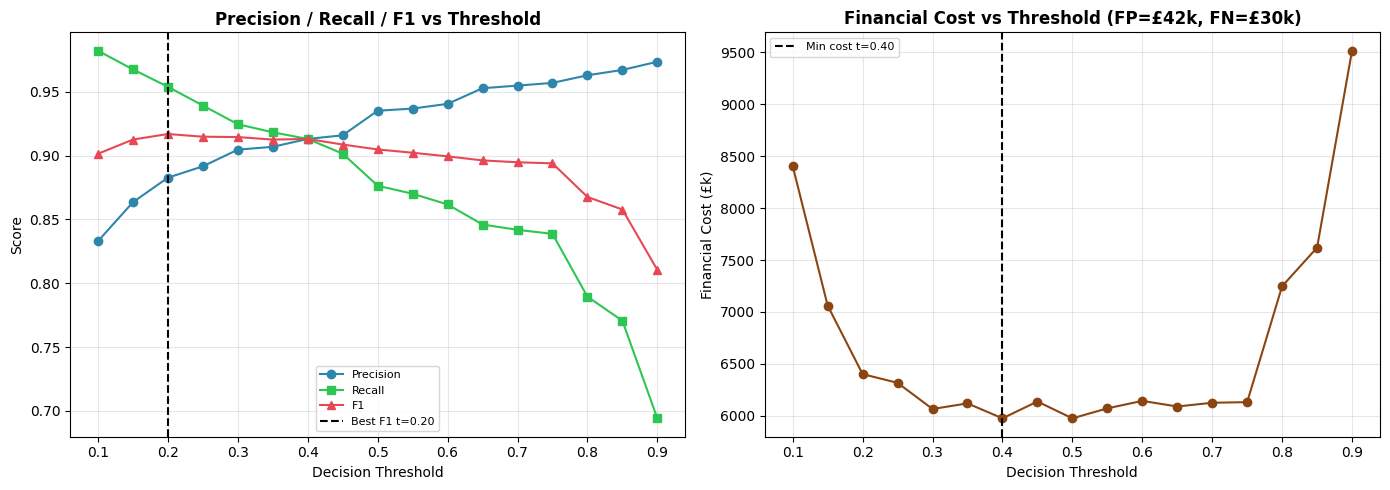

Threshold sweep: Best F1 at t=0.20, Min cost at t=0.40
Saved: dt_threshold_sweep_apprajit.png
Saved: dt_threshold_sweep_apprajit.png


In [19]:
threshold_sweep(best_dt, X_te_dt, y_test,
                os.path.join(FIG_DIR, 'dt_threshold_sweep_apprajit.png'))
print('Saved: dt_threshold_sweep_apprajit.png')

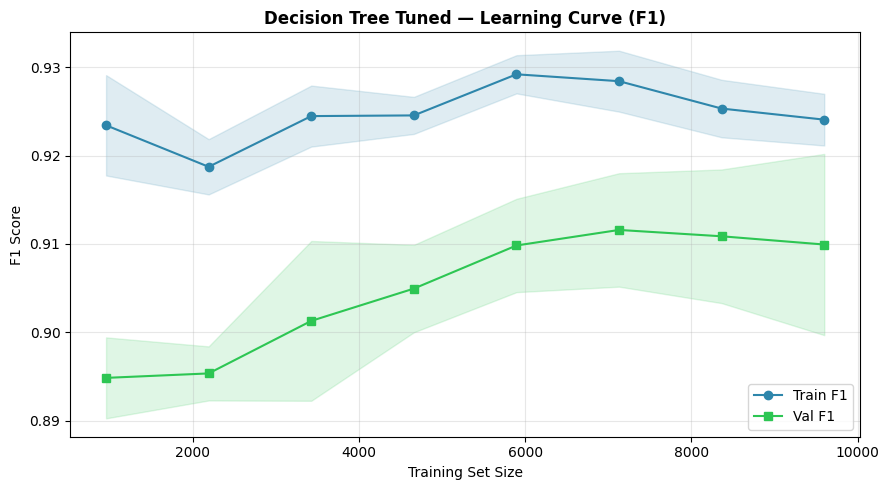

Saved: dt_tuned_learning_curve_apprajit.png
Saved: dt_tuned_learning_curve_apprajit.png


In [20]:
plot_learning_curve(
    best_dt, X_tr_dt, y_train,
    'Decision Tree Tuned — Learning Curve (F1)',
    os.path.join(FIG_DIR, 'dt_tuned_learning_curve_apprajit.png')
)
print('Saved: dt_tuned_learning_curve_apprajit.png')

## Section 19 — Model Comparison Table

SVM (RBF) vs Decision Tree on the test set.

In [21]:
compare = pd.DataFrame([svm_metrics, dt_metrics])
print('\n=== Test Set Comparison: SVM vs Decision Tree ===')
print(compare[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score',
               'ROC_AUC', 'MCC', 'TNR', 'FPR', 'FP_Cost_GBP',
               'Overfit_Gap', 'Overfit_Label']].to_string(index=False))


=== Test Set Comparison: SVM vs Decision Tree ===
                Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
      SVM RBF (Tuned)    0.9107     0.9536  0.9037    0.9280   0.9739 0.8127 0.9229 0.0771      1764000      -0.0024      good fit
Decision Tree (Tuned)    0.8827     0.9352  0.8764    0.9049   0.9545 0.7549 0.8936 0.1064      2436000       0.0183      good fit


## Section 20 — Business Insights

- **SVM's RBF kernel** captures non-linear interactions between Load_Factor, price_per_km, and Competition_Index that a linear boundary would miss
- **Permutation importance** reveals which features genuinely influence the SVM decision boundary despite the model having no native importance metric
- **`class_weight='balanced'`** ensures loss-making routes receive proportionally higher penalty — preventing the classifier from defaulting to the majority class
- **Probability calibration (Platt scaling)** makes the SVM outputs usable as business risk scores, not just binary labels
- SVM's max-margin criterion is well-suited to this problem where the cost of false positives (maintaining unprofitable routes) exceeds the cost of false negatives

## Section 21 — Save Results

In [22]:
import json, pickle, numpy as np, os

compare.to_csv(os.path.join(MEMBER_DIR, 'svm_dt_apprajit.csv'), index=False)
print('Saved: svm_dt_apprajit.csv')

def convert_to_json_serializable(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    elif isinstance(obj, dict): return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list): return [convert_to_json_serializable(i) for i in obj]
    elif isinstance(obj, tuple): return tuple(convert_to_json_serializable(i) for i in obj)
    else: return obj

results_json = {
    'model_name'          : 'SVM RBF',
    'notebook'            : '04_Member3',
    'best_params_primary' : best_params_svm,
    'best_params_dt'      : best_params_dt,
    'val_metrics_primary' : evaluate('SVM-val', y_val, y_val_pred, y_val_prob),
    'test_metrics_primary': evaluate('SVM-test', y_test, y_test_pred, y_test_prob),
    'val_metrics_dt'      : val_metrics_dt,
    'test_metrics_dt'     : test_metrics_dt,
    'svm_enhanced'        : svm_metrics,
    'dt_enhanced'         : dt_metrics,
}
results_json = convert_to_json_serializable(results_json)

with open(os.path.join(MEMBER_DIR, 'results_svm_apprajit.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
print('Saved: results_svm_apprajit.json')

with open(os.path.join(MEMBER_DIR, 'best_svm_apprajit.pkl'), 'wb') as f:
    pickle.dump(best_svm, f)
with open(os.path.join(MEMBER_DIR, 'best_dt_apprajit.pkl'), 'wb') as f:
    pickle.dump(best_dt, f)
print('Saved: best_svm_apprajit.pkl, best_dt_apprajit.pkl')

print('\n=== Final Test Metrics Summary (SVM) ===')
for k, v in svm_metrics.items():
    print(f'  {k:20s}: {v}')

Saved: svm_dt_apprajit.csv
Saved: results_svm_apprajit.json
Saved: best_svm_apprajit.pkl, best_dt_apprajit.pkl

=== Final Test Metrics Summary (SVM) ===
  Model               : SVM RBF (Tuned)
  Accuracy            : 0.9107
  Precision           : 0.9536
  Recall              : 0.9037
  F1_Score            : 0.928
  ROC_AUC             : 0.9739
  MCC                 : 0.8127
  TNR                 : 0.9229
  FPR                 : 0.0771
  FP_Cost_GBP         : 1764000
  Train_F1            : 0.9256
  Overfit_Gap         : -0.0024
  Overfit_Label       : good fit
